<a href="https://colab.research.google.com/github/readytocommit/FinalProject/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
#Learning a CNN for Image Classification


In [25]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
#initialize the seeds for different random number generators

keras.utils.set_random_seed(42)

(x_train,y_train),(x_test,y_test) = keras.datasets.fashion_mnist.load_data()

In [27]:
#Create a python list so that we can go from numbers to descriptions easily.

labels = [
    "T-shirt / top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [52]:
def plot_curves(history):
  plt.clf()
  history_dct = history.history
  loss_value = history_dct["loss"]
  val_loss_values = history_dct["val_loss"]
  epoches = range(1,len(loss_value)+1)
  plt.plot(epoches,loss_value,"bo",label="Training loss")
  plt.plot(epoches,val_loss_values,"b",label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()



In [29]:
def plot_acc_curve(history):
  plt.clf()
  hist_dict = history.history
  acc = hist_dict["accuracy"]
  val_acc = hist_dict["val_accuracy"]
  epoches = range(1,len(acc)+1)
  plt.plot(epoches,acc,"bo",label="Training accuracy")
  plt.plot(epoches,val_acc,"b", label="Validation accuracy")
  plt.title("Training and Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

In [30]:
# A convulational Neural Network

#Convulational Layers

# We will folow the same sequence of steps as we did above:
# Data Preparation
# Define Modeö
# Set optimization parameters
# Train Model
# Evaluate Model





In [31]:
#Data Prep

#Normalize a data in 0-1 range

x_train = x_train / 255.0
x_test = x_test / 255.0


In [32]:
# For reasons that will become clear later when we work with color images, we also need to add another dimension to each example so that it goes from 28*28*1

x_train = np.expand_dims(x_train,-1)
x_test = np.expand_dims(x_test,-1)

x_train.shape

(60000, 28, 28, 1)

In [41]:
#Define a model

Input = keras.Input(shape=x_train.shape[1:])

#the first convolutional block

# convolutional layer

x = keras.layers.Conv2D(32,
                       kernel_size = (2,2),
                       activation = "relu",
                       name = "conv_1")(Input)

#pooling layer
x = keras.layers.MaxPool2D()(x)

#end of the first convolutional layer

#second convolutional block
#convolutional layer
x = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation = "relu",
                        name = "conv_2")(x)
#Pooling layer
x = keras.layers.MaxPool2D()(x)
#end of second convolutional block

#flatten layer

x = keras.layers.Flatten()(x)

#fully connected(denese) ReLU Layer
x = keras.layers.Dense(256,activation="relu")(x)

#Output softmax layer
output = keras.layers.Dense(10,activation="softmax")(x)
model = keras.Model(Input,output)

In [42]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,026 (1.15 MB)

 Trainable params: 302,026 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

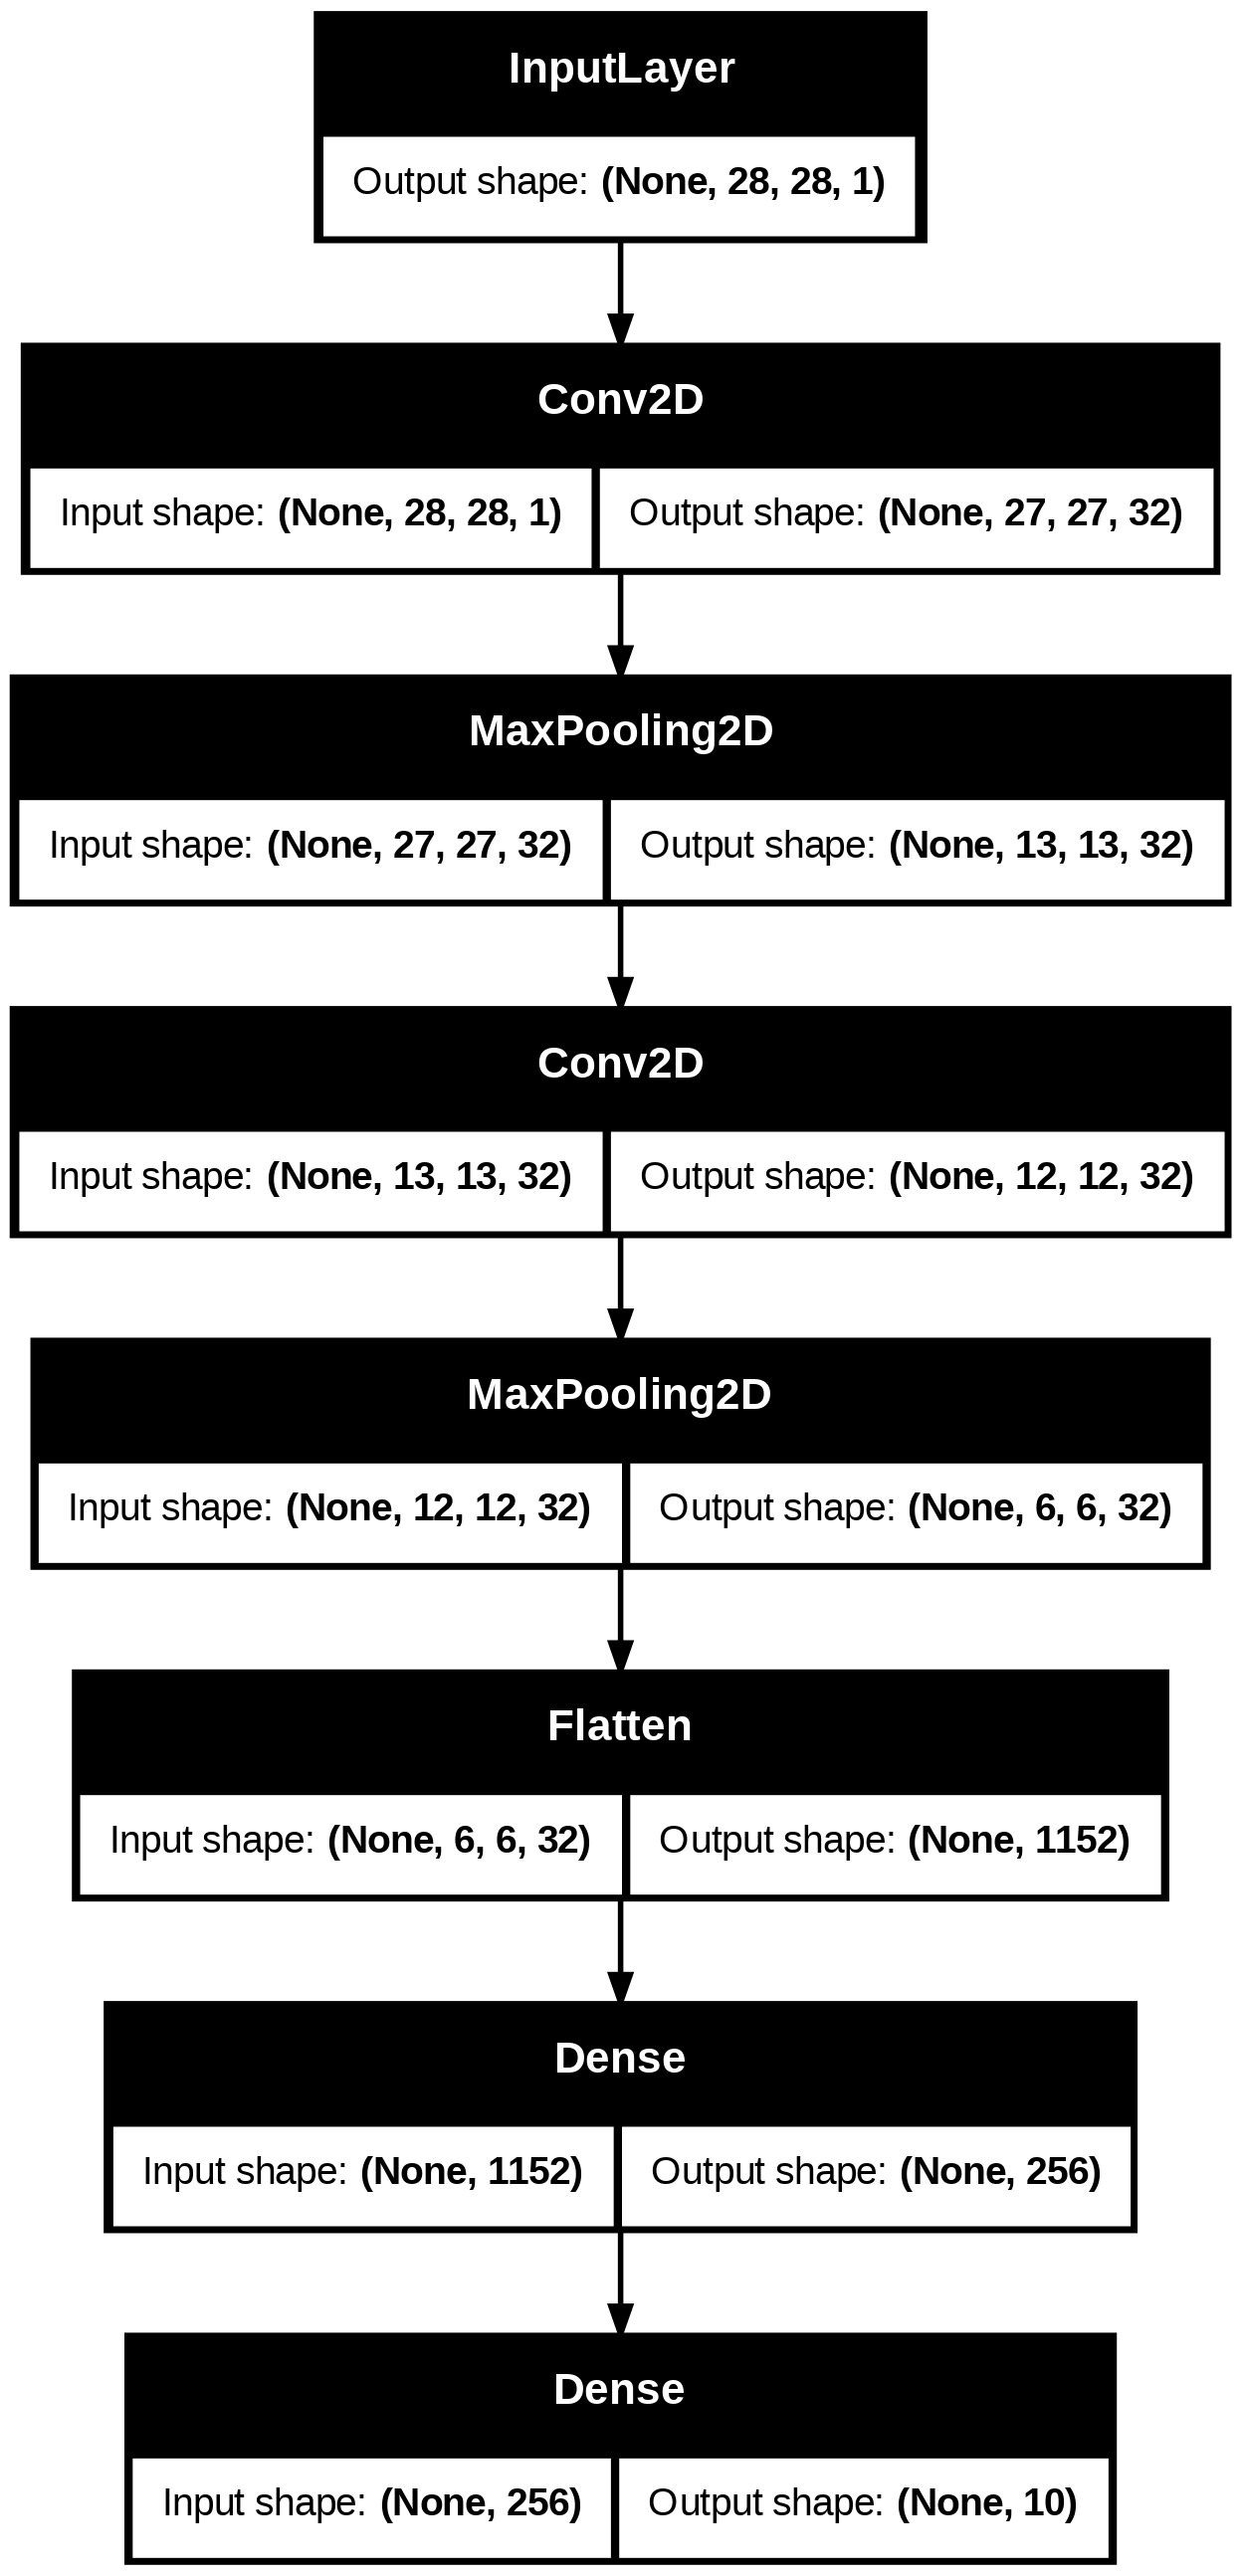

In [44]:
keras.utils.plot_model(model,show_shapes=True)

In [49]:
#Set optimization parameters

model.compile(loss="sparse_categorical_crossentropy",
              optimizer = "adam",
              metrics = ['accuracy'])

In [55]:
history = model.fit(
    x_train,
    y_train,
    batch_size = 64,
    epochs =5,
    validation_split = 0.2,
    verbose = 1.0
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9559 - loss: 0.1246 - val_accuracy: 0.9001 - val_loss: 0.3164
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9610 - loss: 0.1107 - val_accuracy: 0.8972 - val_loss: 0.3420
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9643 - loss: 0.0996 - val_accuracy: 0.8949 - val_loss: 0.3792
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9679 - loss: 0.0898 - val_accuracy: 0.8993 - val_loss: 0.3871
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9714 - loss: 0.0806 - val_accuracy: 0.8945 - val_loss: 0.4108


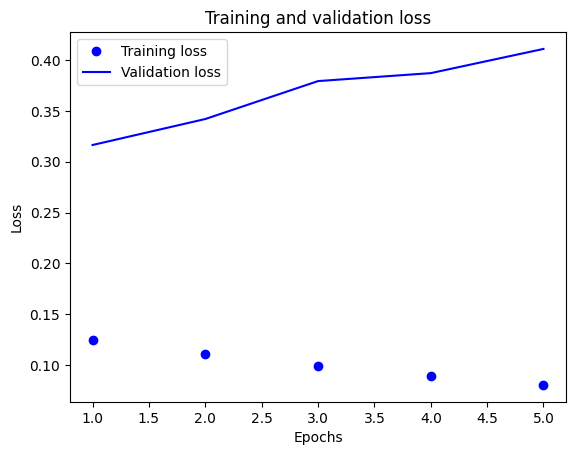

In [56]:
plot_curves(history)

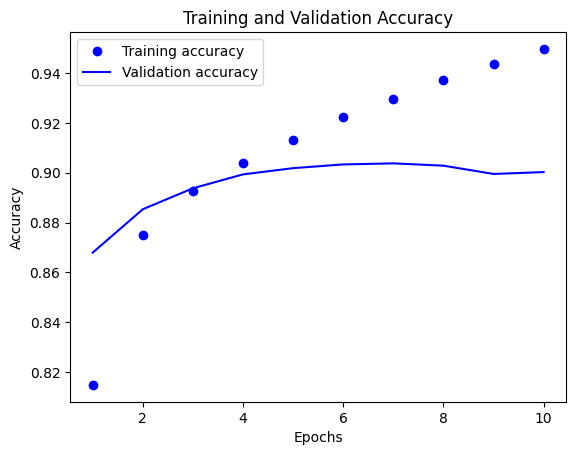

In [54]:
plot_acc_curve(history)

In [57]:
#Now evaluate the model:

score = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8927 - loss: 0.4193


In [ ]:
# The acurracy 0f 0.8927 # Not bad